In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('all_data.csv')

# 1. Nettoyer les noms de colonnes (strip + renommage)
df.columns = df.columns.str.strip()

# 2. Renommer pour plus de clarté
df = df.rename(columns={
    'Life expectancy': 'life_expectancy',
    'Adult Mortality': 'adult_mortality',
    'infant deaths': 'infant_deaths',
    'percentage expenditure': 'health_expenditure_pct',
    'Hepatitis B': 'hepatitis_b',
    'Measles': 'measles',
    'BMI': 'bmi',
    'under-five deaths': 'under_five_deaths',
    'Total expenditure': 'total_expenditure',
    'Diphtheria': 'diphtheria',
    'HIV/AIDS': 'hiv_aids',
    'thinness  1-19 years': 'thinness_1_19',
    'thinness 5-9 years': 'thinness_5_9',
    'Income composition of resources': 'income_composition',
})

# 3. Vérifier les types et valeurs manquantes
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False))

Country                       str
Year                        int64
Status                        str
life_expectancy           float64
adult_mortality           float64
infant_deaths               int64
Alcohol                   float64
health_expenditure_pct    float64
hepatitis_b               float64
measles                     int64
bmi                       float64
under_five_deaths           int64
Polio                     float64
total_expenditure         float64
diphtheria                float64
hiv_aids                  float64
GDP                       float64
Population                float64
thinness_1_19             float64
thinness_5_9              float64
income_composition        float64
Schooling                 float64
dtype: object
Population                652
hepatitis_b               553
GDP                       448
total_expenditure         226
Alcohol                   194
income_composition        167
Schooling                 163
thinness_1_19              3

In [5]:
# La variable cible ne peut pas être imputée
df = df.dropna(subset=['life_expectancy', 'adult_mortality'])
print(df.shape) 

(2928, 22)


In [6]:
# Trier par pays et année pour que l'interpolation fonctionne
df = df.sort_values(['Country', 'Year']).reset_index(drop=True)

# Colonnes à imputer
cols_to_impute = [
    'GDP', 'Population', 'Alcohol', 'hepatitis_b',
    'total_expenditure', 'income_composition', 'Schooling',
    'bmi', 'thinness_1_19', 'thinness_5_9',
    'diphtheria', 'Polio'
]

# 1. Interpolation temporelle par pays
df[cols_to_impute] = (
    df.groupby('Country')[cols_to_impute]
      .transform(lambda group: group.interpolate(method='linear', limit_direction='both'))
)

# 2. Compléter les NaN restants par la médiane du pays
df[cols_to_impute] = (
    df.groupby('Country')[cols_to_impute]
      .transform(lambda group: group.fillna(group.median()))
)

# 3. Sécurité : s'il reste des NaN (pays avec très peu de données), médiane globale
df[cols_to_impute] = df[cols_to_impute].fillna(df[cols_to_impute].median())

# Vérification
print(df.isnull().sum().sum()) 

0


In [7]:
print(df.shape)
print(df.describe())
print(df['Country'].nunique())   # ~183 pays
print(df['Year'].min(), df['Year'].max())  # 2000 2015

(2928, 22)
             Year  life_expectancy  adult_mortality  infant_deaths  \
count  2928.00000      2928.000000      2928.000000    2928.000000   
mean   2007.50000        69.224932       164.796448      30.407445   
std       4.61056         9.523867       124.292079     118.114450   
min    2000.00000        36.300000         1.000000       0.000000   
25%    2003.75000        63.100000        74.000000       0.000000   
50%    2007.50000        72.100000       144.000000       3.000000   
75%    2011.25000        75.700000       228.000000      22.000000   
max    2015.00000        89.000000       723.000000    1800.000000   

           Alcohol  health_expenditure_pct  hepatitis_b        measles  \
count  2928.000000             2928.000000  2928.000000    2928.000000   
mean      4.523885              740.321185    76.463798    2427.855874   
std       4.059071             1990.930605    28.026259   11485.970937   
min       0.010000                0.000000     1.000000       

In [8]:
# Vue d'ensemble
print(df[['life_expectancy', 'GDP', 'Schooling', 'adult_mortality']].describe())

# Pays avec la plus faible / plus forte espérance de vie moyenne
df.groupby('Country')['life_expectancy'].mean().sort_values().head(10)
df.groupby('Country')['life_expectancy'].mean().sort_values().tail(10)

# Différence Developing / Developed
df.groupby('Status')['life_expectancy'].agg(['mean', 'median', 'std'])

       life_expectancy            GDP    Schooling  adult_mortality
count      2928.000000    2928.000000  2928.000000      2928.000000
mean         69.224932    6601.431692    12.016052       164.796448
std           9.523867   13326.789651     3.254407       124.292079
min          36.300000       1.681350     0.000000         1.000000
25%          63.100000     554.658405    10.300000        74.000000
50%          72.100000    1693.453189    12.300000       144.000000
75%          75.700000    4793.630903    14.100000       228.000000
max          89.000000  119172.741800    20.700000       723.000000


,mean,median,std
Status,,,
Developed,79.197852,79.25,3.930942
Developing,67.111465,69.00,9.006092


In [9]:
# Statistiques globales
print(df.describe().T)

                         count          mean           std         min  \
Year                    2928.0  2.007500e+03  4.610560e+00  2000.00000   
life_expectancy         2928.0  6.922493e+01  9.523867e+00    36.30000   
adult_mortality         2928.0  1.647964e+02  1.242921e+02     1.00000   
infant_deaths           2928.0  3.040745e+01  1.181144e+02     0.00000   
Alcohol                 2928.0  4.523885e+00  4.059071e+00     0.01000   
health_expenditure_pct  2928.0  7.403212e+02  1.990931e+03     0.00000   
hepatitis_b             2928.0  7.646380e+01  2.802626e+01     1.00000   
measles                 2928.0  2.427856e+03  1.148597e+04     0.00000   
bmi                     2928.0  3.829129e+01  1.985731e+01     1.00000   
under_five_deaths       2928.0  4.217930e+01  1.607005e+02     0.00000   
Polio                   2928.0  8.230499e+01  2.362616e+01     3.00000   
total_expenditure       2928.0  5.929406e+00  2.489963e+00     0.37000   
diphtheria              2928.0  8.2071

In [10]:
# Espérance de vie moyenne par pays
life_by_country = df.groupby('Country')['life_expectancy'].mean().sort_values()

print("=== 10 pays avec la plus faible espérance de vie ===")
print(life_by_country.head(10))

print("\n=== 10 pays avec la plus forte espérance de vie ===")
print(life_by_country.tail(10))

=== 10 pays avec la plus faible espérance de vie ===
Country
Sierra Leone                46.11250
Central African Republic    48.51250
Lesotho                     48.78125
Angola                      49.01875
Malawi                      49.89375
Côte d'Ivoire               50.38750
Chad                        50.38750
Zimbabwe                    50.48750
Swaziland                   51.32500
Nigeria                     51.35625
Name: life_expectancy, dtype: float64

=== 10 pays avec la plus forte espérance de vie ===
Country
Canada         81.68750
Norway         81.79375
Australia      81.81250
Spain          82.06875
Italy          82.18750
France         82.21875
Switzerland    82.33125
Iceland        82.44375
Sweden         82.51875
Japan          82.53750
Name: life_expectancy, dtype: float64


In [11]:
# Moyenne mondiale par année
world_trend = df.groupby('Year')['life_expectancy'].mean()
print(world_trend)

Year
2000    66.750273
2001    67.128962
2002    67.351366
2003    67.433333
2004    67.646448
2005    68.209290
2006    68.667760
2007    69.036066
2008    69.427869
2009    69.938251
2010    70.048634
2011    70.654098
2012    70.916940
2013    71.236066
2014    71.536612
2015    71.616940
Name: life_expectancy, dtype: float64


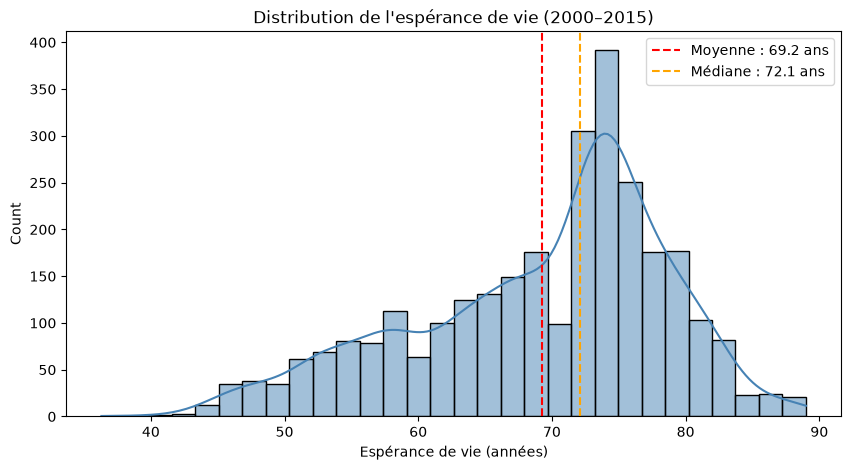

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['life_expectancy'], bins=30, kde=True, color='steelblue')
plt.axvline(df['life_expectancy'].mean(), color='red', linestyle='--',
            label=f"Moyenne : {df['life_expectancy'].mean():.1f} ans")
plt.axvline(df['life_expectancy'].median(), color='orange', linestyle='--',
            label=f"Médiane : {df['life_expectancy'].median():.1f} ans")
plt.title("Distribution de l'espérance de vie (2000–2015)")
plt.xlabel("Espérance de vie (années)")
plt.legend()
plt.show()

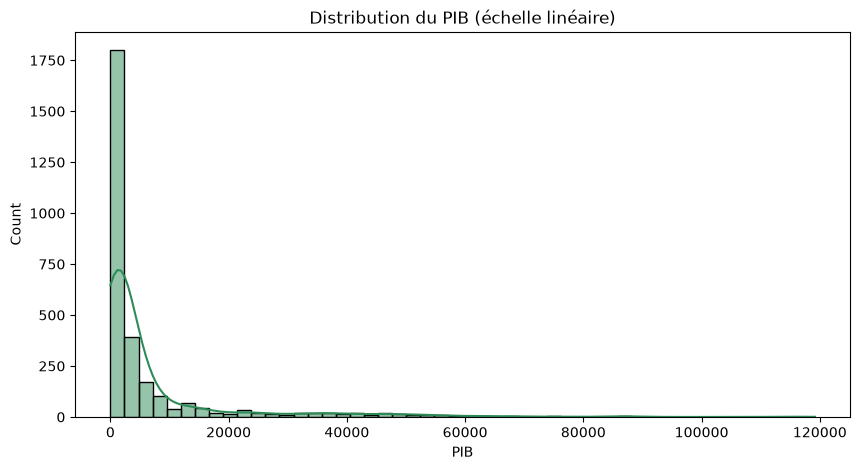

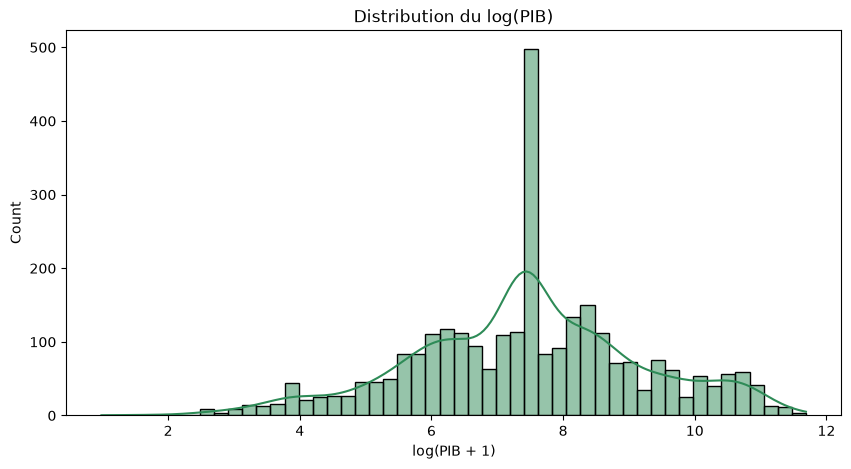

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['GDP'], bins=50, kde=True, color='seagreen')
plt.title("Distribution du PIB (échelle linéaire)")
plt.xlabel("PIB")
plt.show()

# Version log (plus lisible)
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['GDP']), bins=50, kde=True, color='seagreen')
plt.title("Distribution du log(PIB)")
plt.xlabel("log(PIB + 1)")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_13252\1713253170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='life_expectancy', palette='Set2')


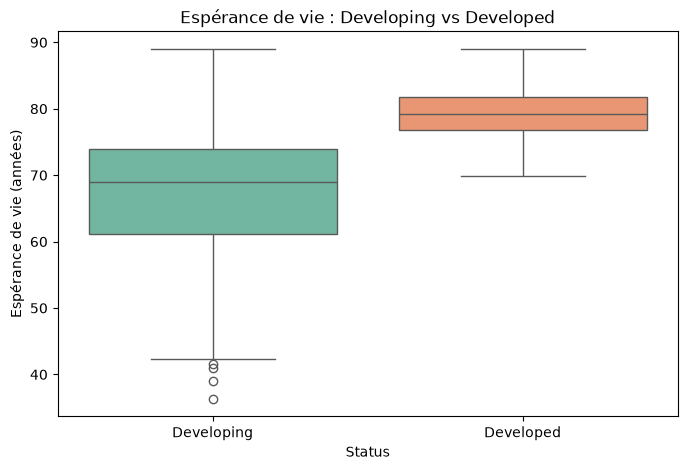

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Status', y='life_expectancy', palette='Set2')
plt.title("Espérance de vie : Developing vs Developed")
plt.ylabel("Espérance de vie (années)")
plt.show()

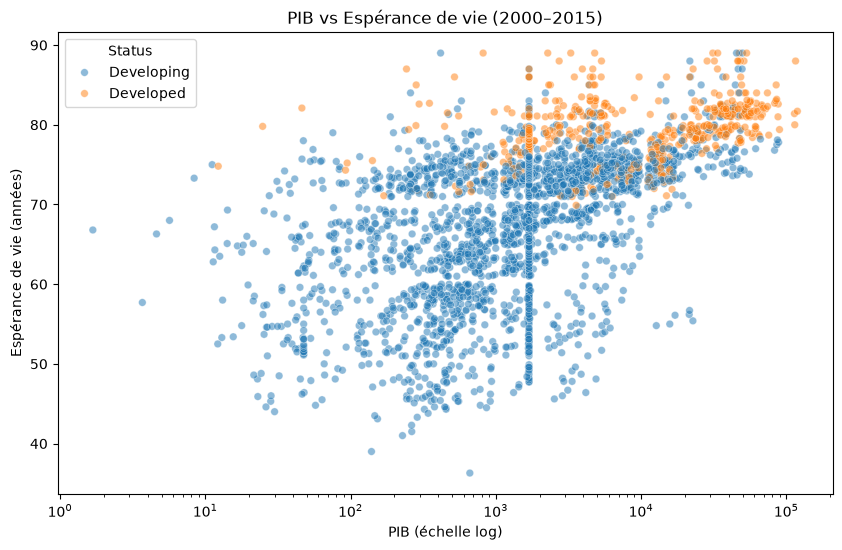

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GDP', y='life_expectancy',
                hue='Status', alpha=0.5, s=30)
plt.xscale('log')
plt.title("PIB vs Espérance de vie (2000–2015)")
plt.xlabel("PIB (échelle log)")
plt.ylabel("Espérance de vie (années)")
plt.show()

Country
Zimbabwe                            21.0
Eritrea                             19.4
Zambia                              18.0
Botswana                            17.9
Rwanda                              17.8
Uganda                              15.7
Malawi                              15.2
Bolivia (Plurinational State of)    14.4
Ethiopia                            13.6
United Republic of Tanzania         12.6
Name: life_expectancy, dtype: float64


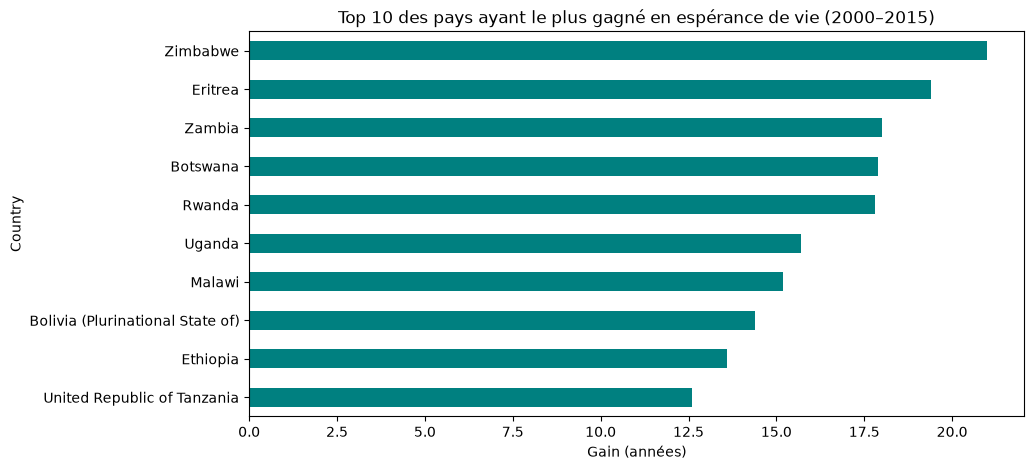

In [16]:
progress = (df[df['Year'] == 2015].set_index('Country')['life_expectancy']
            - df[df['Year'] == 2000].set_index('Country')['life_expectancy'])
top_progress = progress.dropna().sort_values(ascending=False).head(10)
print(top_progress)

plt.figure(figsize=(10, 5))
top_progress.sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 des pays ayant le plus gagné en espérance de vie (2000–2015)")
plt.xlabel("Gain (années)")
plt.show()